# Task 4 — Open-Set Recognition (CIFAR-10 known / CIFAR-100 unknown)

This notebook follows the same structure as Tasks 2/3: numbered sections, idempotent cells, checkpoint-on-best-validation immediately (so nothing is lost to a Kaggle session drop), and shared helper functions reused across methods.

**Pipeline**
0. Setup
1. Data (CIFAR-10 known classes, CIFAR-100 near/far unknown groups)
2. Shared CIFAR-ResNet-18 + training/extraction utilities
3. Vanilla closed-set classifier
4. Post-hoc novelty scores (MSP, MLS, Energy, Mahalanobis)
5. GCSC (RandAugment-strengthened classifier)
6. PROSER (classifier + data placeholders via manifold mixup)
7. Common evaluation table
8. Score-distribution figure + failure-case inspection (required evidence)


## 0. Setup

In [1]:
import os, random, math, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)


Device: cuda


## 1. Data

**Known classes**: all 10 CIFAR-10 classes.

**Unknown groups (CIFAR-100)**: fixed class lists per the assignment spec — a *near* group (semantically close to CIFAR-10 classes, e.g. similar animals/vehicles) and a *far* group (semantically distant). Each group is subsampled to exactly 800 images for a balanced comparison.

We keep an **unaugmented** copy of the training subset for Mahalanobis statistics (augmented features would bias the class-conditional covariance estimate).

In [2]:
# --- Fixed CIFAR-100 near/far unknown class lists (per assignment spec) ---
NEAR_CLASSES = ['bear', 'leopard', 'lion', 'tiger', 'wolf',
                'pickup_truck', 'streetcar', 'tractor', 'tank', 'rocket']
FAR_CLASSES  = ['orchid', 'poppy', 'rose', 'sunflower', 'tulip',
                'clock', 'keyboard', 'telephone', 'wardrobe', 'table']

assert len(NEAR_CLASSES) == 10 and len(FAR_CLASSES) == 10


In [3]:
train_tf_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
eval_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

DATA_ROOT = '/kaggle/working/data'
cifar10_train_full = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=train_tf_aug)
cifar10_train_full_noaug = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=eval_tf)
cifar10_test = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=eval_tf)
cifar100_train = torchvision.datasets.CIFAR100(DATA_ROOT, train=True, download=True, transform=eval_tf)
cifar100_test = torchvision.datasets.CIFAR100(DATA_ROOT, train=False, download=True, transform=eval_tf)


In [4]:
# --- Stratified 90/10 train/val split of CIFAR-10 (seed 6304) ---
set_seed(6304)
targets = np.array(cifar10_train_full.targets)
train_idx, val_idx = [], []
for c in range(10):
    idx_c = np.where(targets == c)[0]
    rng = np.random.RandomState(6304)
    rng.shuffle(idx_c)
    n_val = int(0.1 * len(idx_c))
    val_idx.extend(idx_c[:n_val].tolist())
    train_idx.extend(idx_c[n_val:].tolist())
train_idx = sorted(train_idx)
val_idx = sorted(val_idx)
print(f'Train: {len(train_idx)}  Val: {len(val_idx)}')

cifar10_train_sub = Subset(cifar10_train_full, train_idx)
cifar10_train_sub_noaug = Subset(cifar10_train_full_noaug, train_idx)
cifar10_val_sub = Subset(cifar10_train_full_noaug, val_idx)

train_loader = DataLoader(cifar10_train_sub, batch_size=128, shuffle=True, num_workers=2, drop_last=True)
train_loader_noaug = DataLoader(cifar10_train_sub_noaug, batch_size=256, shuffle=False, num_workers=2)
val_loader = DataLoader(cifar10_val_sub, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(cifar10_test, batch_size=256, shuffle=False, num_workers=2)


Train: 45000  Val: 5000


In [5]:
# --- CIFAR-100 near/far unknown groups, 800 images each (seed 6304) ---
def build_unknown_group(class_names, n_total=800, seed=6304):
    name_to_idx = {name: i for i, name in enumerate(cifar100_test.classes)}
    class_ids = [name_to_idx[n] for n in class_names]
    per_class = n_total // len(class_ids)
    targets100 = np.array(cifar100_test.targets)
    rng = np.random.RandomState(seed)
    chosen = []
    for cid in class_ids:
        idx_c = np.where(targets100 == cid)[0]
        rng.shuffle(idx_c)
        chosen.extend(idx_c[:per_class].tolist())
    chosen = sorted(chosen)
    return Subset(cifar100_test, chosen)

near_unknown = build_unknown_group(NEAR_CLASSES)
far_unknown = build_unknown_group(FAR_CLASSES)
assert len(near_unknown) == 800, len(near_unknown)
assert len(far_unknown) == 800, len(far_unknown)

near_loader = DataLoader(near_unknown, batch_size=256, shuffle=False, num_workers=2)
far_loader = DataLoader(far_unknown, batch_size=256, shuffle=False, num_workers=2)
print('Near unknown:', len(near_unknown), '| Far unknown:', len(far_unknown))


Near unknown: 800 | Far unknown: 800


## 2. Shared CIFAR-ResNet-18 + training/extraction utilities

A single `build_cifar_resnet18()` (3x3 stride-1 stem, no max-pool, suited to native 32x32 images) and a single `train_cifar_classifier(...)` function implement the spec-mandated recipe (SGD lr=0.1, momentum=0.9, weight_decay=5e-4, cosine decay, batch_size=128, seed=6304, 100 epochs, no early stopping, checkpoint saved on every new best validation accuracy). Every method (Vanilla, GCSC, PROSER) reuses this function so the only thing that differs is the data pipeline (RandAugment on/off) or the model wrapper.

In [6]:
from torchvision.models import resnet18

def build_cifar_resnet18(num_classes=10):
    m = resnet18(weights=None, num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m


**Resume support**: every epoch (not just improvements) also writes a `*_resume.pth` alongside the best-model checkpoint, holding model/optimizer/scheduler state plus the current epoch and best-so-far accuracy. If a session dies mid-run, calling this function again detects that file and continues from the next epoch instead of restarting — the earlier version only ever saved the best *weights*, which meant a restart after epoch 1 already had a 'checkpoint' and would wrongly skip straight past the remaining 99 epochs. The resume file is deleted once all `epochs` complete, so a genuinely finished run is never mistaken for an interrupted one.

In [7]:
def train_cifar_classifier(tag, save_path, train_loader_, epochs=100,
                            init_from_state_dict=None, num_classes=10, seed=6304):
    """Shared training loop used by Vanilla and GCSC (they differ only in train_loader_'s
    augmentation pipeline). Checkpoints on every new best validation accuracy, and separately
    saves full resumable state every epoch so an interrupted run can continue rather than
    restart from scratch."""
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model = build_cifar_resnet18(num_classes=num_classes).to(device)
    if init_from_state_dict is not None:
        model.load_state_dict(init_from_state_dict)

    opt = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 1
    best_val_acc = -1.0

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        opt.load_state_dict(ckpt['opt_state'])
        sched.load_state_dict(ckpt['sched_state'])
        start_epoch = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        print(f'[{tag}] Resuming from epoch {start_epoch}/{epochs} (best so far: {best_val_acc:.4f})')

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for x, y in train_loader_:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            opt.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        sched.step()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_acc = v_correct / v_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        torch.save({
            'model_state': model.state_dict(),
            'opt_state': opt.state_dict(),
            'sched_state': sched.state_dict(),
            'epoch': epoch,
            'best_val_acc': best_val_acc,
        }, resume_path)

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f'[{tag}] Epoch {epoch}/{epochs} | Train Loss: {running_loss/total:.4f} | '
                  f'Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f} | Best: {best_val_acc:.4f}')

    print(f'[{tag}] Training complete. Best val acc = {best_val_acc:.4f}. Saved to {save_path}')
    best_model = build_cifar_resnet18(num_classes=num_classes).to(device)
    best_model.load_state_dict(torch.load(save_path, map_location=device))
    if os.path.exists(resume_path):
        os.remove(resume_path)  # training fully finished -- no longer an interrupted run
    return best_model, best_val_acc


In [8]:
def get_feature_extractor(model):
    """Returns a function mapping a batch of images to penultimate-layer features."""
    layers = nn.Sequential(
        model.conv1, model.bn1, model.relu, model.maxpool,
        model.layer1, model.layer2, model.layer3, model.layer4,
        model.avgpool, nn.Flatten(1)
    )
    return layers

@torch.no_grad()
def extract_logits_and_features(model, loader):
    model.eval()
    feat_extractor = get_feature_extractor(model)
    all_logits, all_feats, all_labels = [], [], []
    for x, y in loader:
        x = x.to(device)
        feats = feat_extractor(x)
        logits = model.fc(feats)
        all_logits.append(logits.cpu())
        all_feats.append(feats.cpu())
        all_labels.append(y if torch.is_tensor(y) else torch.tensor(y))
    return torch.cat(all_logits), torch.cat(all_feats), torch.cat(all_labels)

@torch.no_grad()
def test_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct / total


## 3. Vanilla closed-set classifier

In [9]:
VANILLA_PATH = os.path.join(CKPT_DIR, 'vanilla_resnet18.pth')
VANILLA_RESUME = VANILLA_PATH.replace('.pth', '_resume.pth')

# Only skip training entirely if a best checkpoint exists AND there's no resume file --
# a resume file present means an earlier run was interrupted partway through the 100
# epochs, so we must call train_cifar_classifier again to let it continue from there.
if os.path.exists(VANILLA_PATH) and not os.path.exists(VANILLA_RESUME):
    print('Vanilla checkpoint found (training complete), loading instead of retraining.')
    vanilla_model = build_cifar_resnet18().to(device)
    vanilla_model.load_state_dict(torch.load(VANILLA_PATH, map_location=device))
    vanilla_val_acc = test_accuracy(vanilla_model, val_loader)
else:
    vanilla_model, vanilla_val_acc = train_cifar_classifier(
        'Vanilla', VANILLA_PATH, train_loader, epochs=100)

vanilla_test_acc = test_accuracy(vanilla_model, test_loader)
print(f'Vanilla closed-set test accuracy: {vanilla_test_acc:.4f}')


Vanilla checkpoint found (training complete), loading instead of retraining.
Vanilla closed-set test accuracy: 0.9458


In [10]:
# Extract logits/features across every split we need for scoring (Section 4)
vanilla_train_logits, vanilla_train_feats, vanilla_train_labels = extract_logits_and_features(vanilla_model, train_loader_noaug)
vanilla_val_logits, vanilla_val_feats, vanilla_val_labels = extract_logits_and_features(vanilla_model, val_loader)
vanilla_test_logits, vanilla_test_feats, vanilla_test_labels = extract_logits_and_features(vanilla_model, test_loader)
vanilla_near_logits, vanilla_near_feats, _ = extract_logits_and_features(vanilla_model, near_loader)
vanilla_far_logits, vanilla_far_feats, _ = extract_logits_and_features(vanilla_model, far_loader)
print('Extraction complete:', vanilla_train_feats.shape, vanilla_test_feats.shape, vanilla_near_feats.shape, vanilla_far_feats.shape)


Extraction complete: torch.Size([45000, 512]) torch.Size([10000, 512]) torch.Size([800, 512]) torch.Size([800, 512])


## 4. Post-hoc novelty scores (MSP, MLS, Energy, Mahalanobis)

All four scores are computed from the **same** Vanilla model's logits/features — no retraining. Mahalanobis uses a shared (tied) diagonal covariance fit on the **unaugmented** train features, per-class means, with a `+1e-6` diagonal jitter for numerical stability.

In [11]:
def msp_score(logits):
    return F.softmax(logits, dim=1).max(1).values

def mls_score(logits):
    return logits.max(1).values

def energy_score(logits, T=1.0):
    return T * torch.logsumexp(logits / T, dim=1)

def fit_mahalanobis(train_feats, train_labels, num_classes=10, eps=1e-6):
    feats = train_feats.numpy()
    labels = train_labels.numpy()
    d = feats.shape[1]
    means = np.zeros((num_classes, d))
    centered_all = []
    for c in range(num_classes):
        fc = feats[labels == c]
        means[c] = fc.mean(0)
        centered_all.append(fc - means[c])
    centered_all = np.concatenate(centered_all, axis=0)
    var = centered_all.var(axis=0) + eps  # shared diagonal covariance
    return means, var

def mahalanobis_score(feats, means, var):
    feats = feats.numpy()
    dists = np.stack([((feats - means[c])**2 / var).sum(1) for c in range(means.shape[0])], axis=1)
    min_dist = dists.min(1)
    return torch.from_numpy(-min_dist)  # higher = more in-distribution

maha_means, maha_var = fit_mahalanobis(vanilla_train_feats, vanilla_train_labels)


In [12]:
def evaluate_scores(score_fn, name, val_logits, val_feats, test_logits, test_feats,
                     near_logits, near_feats, far_logits, far_feats, needs_feats=False):
    if needs_feats:
        s_val = score_fn(val_feats)
        s_test = score_fn(test_feats)
        s_near = score_fn(near_feats)
        s_far = score_fn(far_feats)
    else:
        s_val = score_fn(val_logits)
        s_test = score_fn(test_logits)
        s_near = score_fn(near_logits)
        s_far = score_fn(far_logits)

    y_true_near = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_near))])
    y_score_near = np.concatenate([s_test.numpy(), s_near.numpy()])
    auroc_near = roc_auc_score(y_true_near, y_score_near)

    y_true_far = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_far))])
    y_score_far = np.concatenate([s_test.numpy(), s_far.numpy()])
    auroc_far = roc_auc_score(y_true_far, y_score_far)

    y_true_all = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_near) + len(s_far))])
    y_score_all = np.concatenate([s_test.numpy(), s_near.numpy(), s_far.numpy()])
    auroc_all = roc_auc_score(y_true_all, y_score_all)

    # Validation-calibrated threshold: 5th percentile of ID validation scores -> 95% TPR target
    threshold = np.percentile(s_val.numpy(), 5)
    test_accept_rate = (s_test.numpy() >= threshold).mean()
    near_reject_rate = (s_near.numpy() < threshold).mean()
    far_reject_rate = (s_far.numpy() < threshold).mean()

    print(f'--- {name} ---')
    print(f'AUROC  near={auroc_near:.4f}  far={auroc_far:.4f}  all={auroc_all:.4f}')
    print(f'Threshold(val p5)={threshold:.4f} | Test accept={test_accept_rate:.4f} | '
          f'Near reject={near_reject_rate:.4f} | Far reject={far_reject_rate:.4f}')
    return {
        'name': name, 'auroc_near': auroc_near, 'auroc_far': auroc_far, 'auroc_all': auroc_all,
        'threshold': threshold, 'test_accept': test_accept_rate,
        'near_reject': near_reject_rate, 'far_reject': far_reject_rate,
        's_val': s_val, 's_test': s_test, 's_near': s_near, 's_far': s_far,
    }


In [13]:
posthoc_results = {}
posthoc_results['MSP'] = evaluate_scores(
    msp_score, 'Vanilla + MSP',
    vanilla_val_logits, vanilla_val_feats, vanilla_test_logits, vanilla_test_feats,
    vanilla_near_logits, vanilla_near_feats, vanilla_far_logits, vanilla_far_feats)

posthoc_results['MLS'] = evaluate_scores(
    mls_score, 'Vanilla + MLS',
    vanilla_val_logits, vanilla_val_feats, vanilla_test_logits, vanilla_test_feats,
    vanilla_near_logits, vanilla_near_feats, vanilla_far_logits, vanilla_far_feats)

posthoc_results['Energy'] = evaluate_scores(
    energy_score, 'Vanilla + Energy',
    vanilla_val_logits, vanilla_val_feats, vanilla_test_logits, vanilla_test_feats,
    vanilla_near_logits, vanilla_near_feats, vanilla_far_logits, vanilla_far_feats)

maha_fn = lambda feats: mahalanobis_score(feats, maha_means, maha_var)
posthoc_results['Mahalanobis'] = evaluate_scores(
    maha_fn, 'Vanilla + Mahalanobis',
    vanilla_val_logits, vanilla_val_feats, vanilla_test_logits, vanilla_test_feats,
    vanilla_near_logits, vanilla_near_feats, vanilla_far_logits, vanilla_far_feats, needs_feats=True)


--- Vanilla + MSP ---
AUROC  near=0.8058  far=0.8896  all=0.8477
Threshold(val p5)=0.8340 | Test accept=0.9474 | Near reject=0.2800 | Far reject=0.4675
--- Vanilla + MLS ---
AUROC  near=0.7865  far=0.8889  all=0.8377
Threshold(val p5)=5.8854 | Test accept=0.9528 | Near reject=0.3262 | Far reject=0.5337
--- Vanilla + Energy ---
AUROC  near=0.7868  far=0.8894  all=0.8381
Threshold(val p5)=6.0737 | Test accept=0.9533 | Near reject=0.3237 | Far reject=0.5337
--- Vanilla + Mahalanobis ---
AUROC  near=0.8063  far=0.9125  all=0.8594
Threshold(val p5)=-2817.7003 | Test accept=0.9507 | Near reject=0.2412 | Far reject=0.5050


## 5. GCSC (RandAugment-strengthened classifier)

Same architecture and training recipe as Vanilla; the only change is a stronger augmentation pipeline (`RandAugment(num_ops=2, magnitude=9)`) intended to make the learned decision boundary more conservative and better calibrated for open-set rejection. Evaluated with MLS (the strongest post-hoc score for Vanilla is generally MLS/Energy; we report MLS here per spec).

In [14]:
train_tf_randaug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar10_train_full_randaug = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=train_tf_randaug)
cifar10_train_sub_randaug = Subset(cifar10_train_full_randaug, train_idx)
train_loader_randaug = DataLoader(cifar10_train_sub_randaug, batch_size=128, shuffle=True, num_workers=2, drop_last=True)


In [15]:
GCSC_PATH = os.path.join(CKPT_DIR, 'gcsc_resnet18.pth')
GCSC_RESUME = GCSC_PATH.replace('.pth', '_resume.pth')

if os.path.exists(GCSC_PATH) and not os.path.exists(GCSC_RESUME):
    print('GCSC checkpoint found (training complete), loading instead of retraining.')
    gcsc_model = build_cifar_resnet18().to(device)
    gcsc_model.load_state_dict(torch.load(GCSC_PATH, map_location=device))
else:
    gcsc_model, gcsc_val_acc = train_cifar_classifier(
        'GCSC', GCSC_PATH, train_loader_randaug, epochs=100)

gcsc_test_acc = test_accuracy(gcsc_model, test_loader)
print(f'GCSC closed-set test accuracy: {gcsc_test_acc:.4f}')


GCSC checkpoint found (training complete), loading instead of retraining.
GCSC closed-set test accuracy: 0.8694


In [16]:
gcsc_val_logits, gcsc_val_feats, _ = extract_logits_and_features(gcsc_model, val_loader)
gcsc_test_logits, gcsc_test_feats, _ = extract_logits_and_features(gcsc_model, test_loader)
gcsc_near_logits, gcsc_near_feats, _ = extract_logits_and_features(gcsc_model, near_loader)
gcsc_far_logits, gcsc_far_feats, _ = extract_logits_and_features(gcsc_model, far_loader)

gcsc_results = evaluate_scores(
    mls_score, 'GCSC + MLS',
    gcsc_val_logits, gcsc_val_feats, gcsc_test_logits, gcsc_test_feats,
    gcsc_near_logits, gcsc_near_feats, gcsc_far_logits, gcsc_far_feats)


--- GCSC + MLS ---
AUROC  near=0.7298  far=0.8776  all=0.8037
Threshold(val p5)=3.0586 | Test accept=0.9574 | Near reject=0.1212 | Far reject=0.3563


## 6. PROSER (classifier + data placeholders via manifold mixup)

PROSER augments the Vanilla classifier with a small number of extra "dummy" output units that learn to represent open-space, trained with two placeholder losses:

- **Classifier placeholders**: for each real sample, the dummy logits are pushed to be the second-highest overall (encouraging every dummy unit to act as a plausible "runner-up" class almost anywhere in feature space) — implemented as a manifold-mixup-free cross-entropy variant, weight β=1.
- **Data placeholders**: pairs of different-class samples are mixed at an intermediate layer (`layer2`/`layer3` split) via `λ ~ Beta(2,2)`, and the mixed feature is pushed to score highly on the dummy classifier (weight γ=0.1) — synthesizing open-space training signal without any real unknown data.

The backbone/classifier weights are initialized from the Vanilla checkpoint; 5 randomly initialized dummy units are appended and only the network is fine-tuned for 50 epochs (per spec).

In [17]:
class PROSER_ResNet(nn.Module):
    """Wraps a CIFAR-ResNet18, splitting forward into pre/post layer2-layer3 boundary so
    manifold mixup can be injected at that intermediate representation. Appends n_dummy extra
    output units to the classifier head."""
    def __init__(self, base_model, num_classes=10, n_dummy=5):
        super().__init__()
        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool
        self.layer1 = base_model.layer1
        self.layer2 = base_model.layer2
        self.layer3 = base_model.layer3
        self.layer4 = base_model.layer4
        self.avgpool = base_model.avgpool
        in_feats = base_model.fc.in_features
        self.fc = nn.Linear(in_feats, num_classes + n_dummy)
        with torch.no_grad():
            self.fc.weight[:num_classes].copy_(base_model.fc.weight)
            self.fc.bias[:num_classes].copy_(base_model.fc.bias)
        self.num_classes = num_classes
        self.n_dummy = n_dummy

    def forward_pre(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        return x  # intermediate rep, mixup injection point

    def forward_post(self, h):
        x = self.layer3(h)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

    def forward(self, x):
        return self.forward_post(self.forward_pre(x))


In [18]:
def train_proser(vanilla_model, save_path, epochs=50, beta=1.0, gamma=0.1, n_dummy=5, seed=6304):
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model = PROSER_ResNet(vanilla_model, num_classes=10, n_dummy=n_dummy).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    num_classes = 10

    start_epoch = 1
    best_val_acc = -1.0

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        opt.load_state_dict(ckpt['opt_state'])
        sched.load_state_dict(ckpt['sched_state'])
        start_epoch = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        print(f'[PROSER] Resuming from epoch {start_epoch}/{epochs} (best so far: {best_val_acc:.4f})')

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            bsz = x.size(0)
            half = bsz // 2
            if half == 0:
                continue
            x1, y1 = x[:half], y[:half]
            x2, y2 = x[half:2*half], y[half:2*half]

            opt.zero_grad()

            # --- Classifier placeholder loss (on x1): push dummy logits to be runner-up ---
            logits1 = model(x1)
            known_logits1 = logits1[:, :num_classes]
            dummy_max1 = logits1[:, num_classes:].max(1).values
            ce_loss = F.cross_entropy(known_logits1, y1)
            top2 = known_logits1.clone()
            top2.scatter_(1, y1.unsqueeze(1), float('-inf'))
            runner_up1 = top2.max(1).values
            placeholder_cls_loss = F.relu(runner_up1 - dummy_max1 + 1.0).mean()

            # --- Data placeholder loss (on x2 pairs): manifold mixup at layer2/3 boundary ---
            perm = torch.randperm(half, device=device)
            x2b, y2b = x2[perm], y2[perm]
            diff_mask = (y2 != y2b)
            h2 = model.forward_pre(x2)
            h2b = model.forward_pre(x2b)
            lam = np.random.beta(2.0, 2.0)
            h_mix = lam * h2 + (1 - lam) * h2b
            mix_logits = model.forward_post(h_mix)
            known_mix = mix_logits[:, :num_classes]
            dummy_mix = mix_logits[:, num_classes:].max(1).values
            known_mix_max = known_mix.max(1).values
            if diff_mask.any():
                data_placeholder_loss = F.relu(known_mix_max[diff_mask] - dummy_mix[diff_mask] + 1.0).mean()
            else:
                data_placeholder_loss = torch.tensor(0.0, device=device)

            loss = ce_loss + beta * placeholder_cls_loss + gamma * data_placeholder_loss
            loss.backward()
            opt.step()

            running_loss += loss.item() * bsz
            correct += (known_logits1.argmax(1) == y1).sum().item()
            total += half
        sched.step()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)[:, :num_classes]
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_acc = v_correct / v_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        torch.save({
            'model_state': model.state_dict(),
            'opt_state': opt.state_dict(),
            'sched_state': sched.state_dict(),
            'epoch': epoch,
            'best_val_acc': best_val_acc,
        }, resume_path)

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f'[PROSER] Epoch {epoch}/{epochs} | Loss: {running_loss/max(total,1):.4f} | '
                  f'Val Acc: {val_acc:.4f} | Best: {best_val_acc:.4f}')

    print(f'[PROSER] Training complete. Best val acc = {best_val_acc:.4f}. Saved to {save_path}')
    best_model = PROSER_ResNet(vanilla_model, num_classes=10, n_dummy=n_dummy).to(device)
    best_model.load_state_dict(torch.load(save_path, map_location=device))
    if os.path.exists(resume_path):
        os.remove(resume_path)
    return best_model, best_val_acc


In [19]:
PROSER_PATH = os.path.join(CKPT_DIR, 'proser_resnet18.pth')
PROSER_RESUME = PROSER_PATH.replace('.pth', '_resume.pth')

if os.path.exists(PROSER_PATH) and not os.path.exists(PROSER_RESUME):
    print('PROSER checkpoint found (training complete), loading instead of retraining.')
    proser_model = PROSER_ResNet(vanilla_model, num_classes=10, n_dummy=5).to(device)
    proser_model.load_state_dict(torch.load(PROSER_PATH, map_location=device))
else:
    proser_model, proser_val_acc = train_proser(vanilla_model, PROSER_PATH, epochs=50)


[PROSER] Epoch 1/50 | Loss: 0.4104 | Val Acc: 0.9068 | Best: 0.9068
[PROSER] Epoch 5/50 | Loss: 0.2508 | Val Acc: 0.9128 | Best: 0.9128
[PROSER] Epoch 10/50 | Loss: 0.1942 | Val Acc: 0.9188 | Best: 0.9226
[PROSER] Epoch 15/50 | Loss: 0.1514 | Val Acc: 0.9230 | Best: 0.9230
[PROSER] Epoch 20/50 | Loss: 0.1046 | Val Acc: 0.9240 | Best: 0.9310
[PROSER] Epoch 25/50 | Loss: 0.0719 | Val Acc: 0.9312 | Best: 0.9312
[PROSER] Epoch 30/50 | Loss: 0.0328 | Val Acc: 0.9422 | Best: 0.9422
[PROSER] Epoch 35/50 | Loss: 0.0146 | Val Acc: 0.9438 | Best: 0.9450
[PROSER] Epoch 40/50 | Loss: 0.0104 | Val Acc: 0.9448 | Best: 0.9480
[PROSER] Epoch 45/50 | Loss: 0.0084 | Val Acc: 0.9452 | Best: 0.9480
[PROSER] Epoch 50/50 | Loss: 0.0089 | Val Acc: 0.9440 | Best: 0.9480
[PROSER] Training complete. Best val acc = 0.9480. Saved to /kaggle/working/checkpoints/proser_resnet18.pth


In [20]:
@torch.no_grad()
def proser_scores(model, loader, num_classes=10):
    model.eval()
    mls_scores, ph_scores, all_logits = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        known = logits[:, :num_classes]
        dummy = logits[:, num_classes:]
        mls_scores.append(known.max(1).values.cpu())
        ph_scores.append((known.max(1).values - dummy.max(1).values).cpu())
        all_logits.append(known.cpu())
    return torch.cat(mls_scores), torch.cat(ph_scores), torch.cat(all_logits)

proser_val_mls, proser_val_ph, proser_val_known_logits = proser_scores(proser_model, val_loader)
proser_test_mls, proser_test_ph, proser_test_known_logits = proser_scores(proser_model, test_loader)
proser_near_mls, proser_near_ph, _ = proser_scores(proser_model, near_loader)
proser_far_mls, proser_far_ph, _ = proser_scores(proser_model, far_loader)

proser_test_acc = (proser_test_known_logits.argmax(1) == torch.tensor(cifar10_test.targets)).float().mean().item()
print(f'PROSER closed-set test accuracy: {proser_test_acc:.4f}')


PROSER closed-set test accuracy: 0.9424


In [21]:
def evaluate_precomputed(name, s_val, s_test, s_near, s_far):
    y_true_near = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_near))])
    y_score_near = np.concatenate([s_test.numpy(), s_near.numpy()])
    auroc_near = roc_auc_score(y_true_near, y_score_near)

    y_true_far = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_far))])
    y_score_far = np.concatenate([s_test.numpy(), s_far.numpy()])
    auroc_far = roc_auc_score(y_true_far, y_score_far)

    y_true_all = np.concatenate([np.ones(len(s_test)), np.zeros(len(s_near) + len(s_far))])
    y_score_all = np.concatenate([s_test.numpy(), s_near.numpy(), s_far.numpy()])
    auroc_all = roc_auc_score(y_true_all, y_score_all)

    threshold = np.percentile(s_val.numpy(), 5)
    test_accept_rate = (s_test.numpy() >= threshold).mean()
    near_reject_rate = (s_near.numpy() < threshold).mean()
    far_reject_rate = (s_far.numpy() < threshold).mean()

    print(f'--- {name} ---')
    print(f'AUROC  near={auroc_near:.4f}  far={auroc_far:.4f}  all={auroc_all:.4f}')
    print(f'Threshold(val p5)={threshold:.4f} | Test accept={test_accept_rate:.4f} | '
          f'Near reject={near_reject_rate:.4f} | Far reject={far_reject_rate:.4f}')
    return {
        'name': name, 'auroc_near': auroc_near, 'auroc_far': auroc_far, 'auroc_all': auroc_all,
        'threshold': threshold, 'test_accept': test_accept_rate,
        'near_reject': near_reject_rate, 'far_reject': far_reject_rate,
        's_val': s_val, 's_test': s_test, 's_near': s_near, 's_far': s_far,
    }

proser_mls_results = evaluate_precomputed('PROSER + MLS', proser_val_mls, proser_test_mls, proser_near_mls, proser_far_mls)
proser_ph_results = evaluate_precomputed('PROSER + Placeholder', proser_val_ph, proser_test_ph, proser_near_ph, proser_far_ph)


--- PROSER + MLS ---
AUROC  near=0.7823  far=0.8739  all=0.8281
Threshold(val p5)=4.5187 | Test accept=0.9510 | Near reject=0.2875 | Far reject=0.4900
--- PROSER + Placeholder ---
AUROC  near=0.8070  far=0.9272  all=0.8671
Threshold(val p5)=-6.2784 | Test accept=0.9530 | Near reject=0.2675 | Far reject=0.6025


## 7. Common evaluation table

In [22]:
import pandas as pd

rows = []
for key in ['MSP', 'MLS', 'Energy', 'Mahalanobis']:
    r = posthoc_results[key]
    rows.append(['Vanilla', key, vanilla_test_acc, r['auroc_near'], r['auroc_far'], r['auroc_all'],
                 r['test_accept'], r['near_reject'], r['far_reject']])

rows.append(['GCSC', 'MLS', gcsc_test_acc, gcsc_results['auroc_near'], gcsc_results['auroc_far'],
             gcsc_results['auroc_all'], gcsc_results['test_accept'], gcsc_results['near_reject'], gcsc_results['far_reject']])

rows.append(['PROSER', 'MLS', proser_test_acc, proser_mls_results['auroc_near'], proser_mls_results['auroc_far'],
             proser_mls_results['auroc_all'], proser_mls_results['test_accept'], proser_mls_results['near_reject'], proser_mls_results['far_reject']])
rows.append(['PROSER', 'Placeholder', proser_test_acc, proser_ph_results['auroc_near'], proser_ph_results['auroc_far'],
             proser_ph_results['auroc_all'], proser_ph_results['test_accept'], proser_ph_results['near_reject'], proser_ph_results['far_reject']])

summary_df = pd.DataFrame(rows, columns=['Method', 'Score', 'Closed-Set Acc', 'AUROC(near)', 'AUROC(far)',
                                          'AUROC(all)', 'Test Accept', 'Near Reject', 'Far Reject'])
summary_df


,Method,Score,Closed-Set Acc,AUROC(near),AUROC(far),AUROC(all),Test Accept,Near Reject,Far Reject
0,Vanilla,MSP,0.9458,0.805759,0.889638,0.847699,0.9474,0.28000,0.46750
1,Vanilla,MLS,0.9458,0.786487,0.888888,0.837688,0.9528,0.32625,0.53375
2,Vanilla,Energy,0.9458,0.786773,0.889394,0.838084,0.9533,0.32375,0.53375
3,Vanilla,Mahalanobis,0.9458,0.806255,0.912454,0.859355,0.9507,0.24125,0.50500
4,GCSC,MLS,0.8694,0.729797,0.877575,0.803686,0.9574,0.12125,0.35625
5,PROSER,MLS,0.9424,0.782271,0.873919,0.828095,0.9510,0.28750,0.49000
6,PROSER,Placeholder,0.9424,0.807004,0.927234,0.867119,0.9530,0.26750,0.60250


## 8. Score-distribution figure + failure-case inspection

Required evidence: (a) the score distributions for known-test vs. near-unknown vs. far-unknown, for MSP / MLS / Mahalanobis; (b) 3+ concrete near- and far-unknown examples that were **incorrectly accepted** (scored above the Vanilla MLS validation threshold) — i.e. the open-set failures.

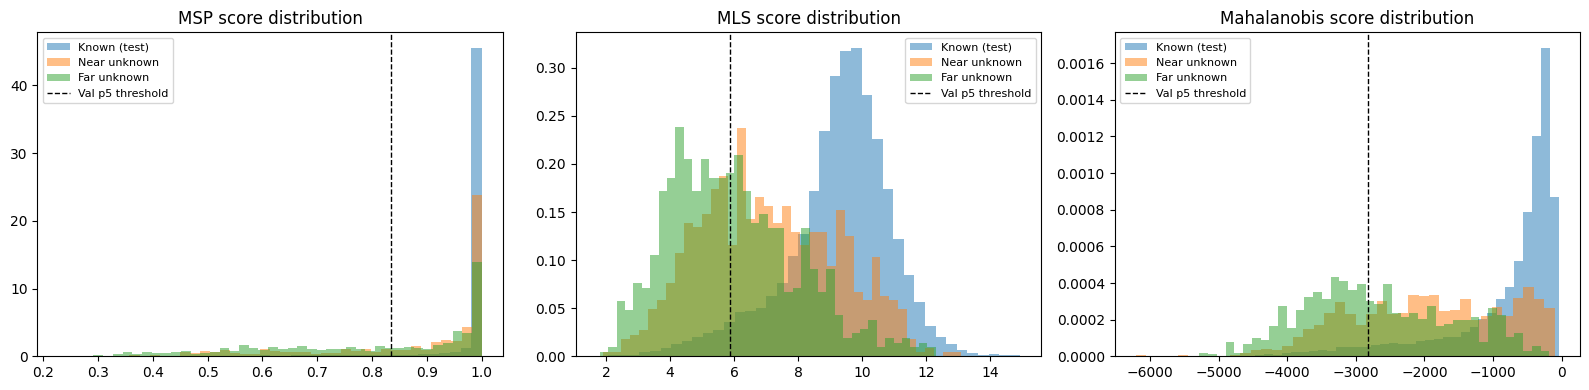

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key in zip(axes, ['MSP', 'MLS', 'Mahalanobis']):
    r = posthoc_results[key]
    ax.hist(r['s_test'].numpy(), bins=40, alpha=0.5, label='Known (test)', density=True)
    ax.hist(r['s_near'].numpy(), bins=40, alpha=0.5, label='Near unknown', density=True)
    ax.hist(r['s_far'].numpy(), bins=40, alpha=0.5, label='Far unknown', density=True)
    ax.axvline(r['threshold'], color='k', linestyle='--', linewidth=1, label='Val p5 threshold')
    ax.set_title(f'{key} score distribution')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/score_distributions.png', dpi=150)
plt.show()


Near-unknown incorrectly accepted: 539 / 800
Far-unknown incorrectly accepted: 373 / 800


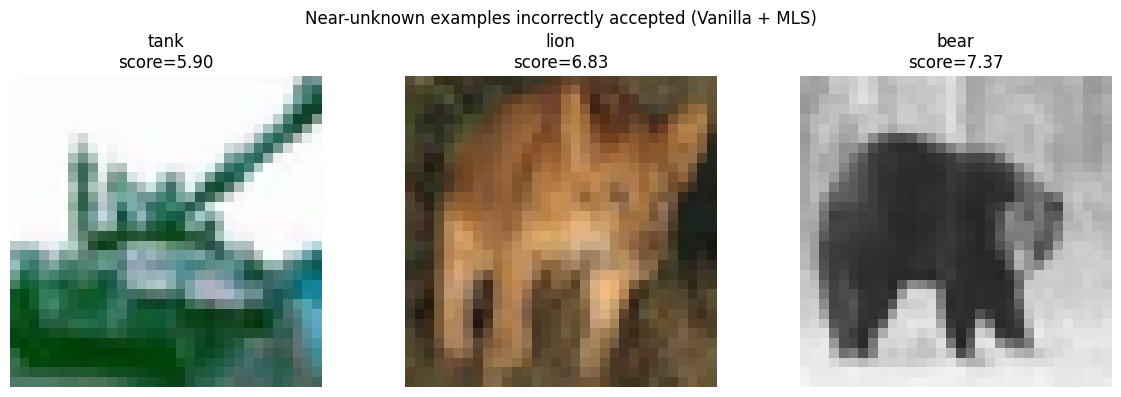

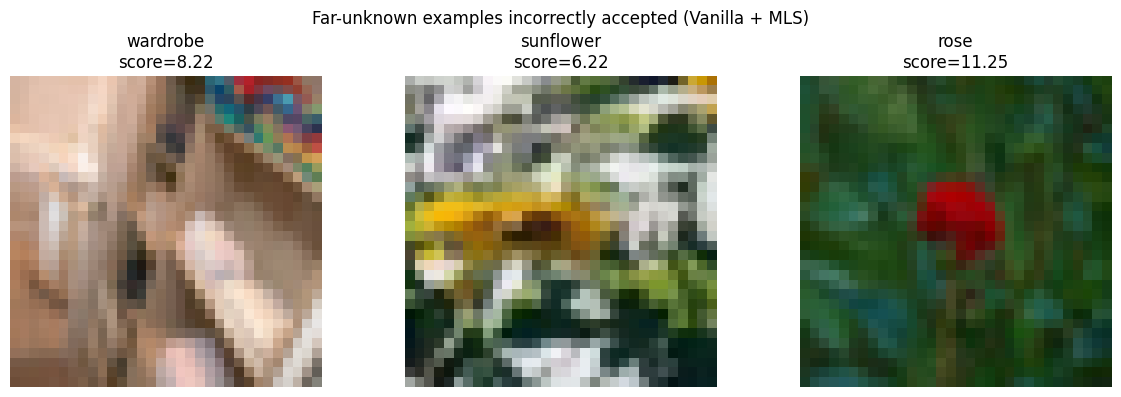

In [24]:
# --- Incorrectly-accepted near/far examples at the Vanilla MLS threshold ---
mls_r = posthoc_results['MLS']
threshold = mls_r['threshold']

near_accepted_idx = np.where(mls_r['s_near'].numpy() >= threshold)[0]
far_accepted_idx = np.where(mls_r['s_far'].numpy() >= threshold)[0]
print(f'Near-unknown incorrectly accepted: {len(near_accepted_idx)} / {len(near_unknown)}')
print(f'Far-unknown incorrectly accepted: {len(far_accepted_idx)} / {len(far_unknown)}')

def show_failures(dataset, class_names, idx_list, score_tensor, title, n=3):
    n = min(n, len(idx_list))
    if n == 0:
        print(f'No incorrectly-accepted examples found for {title}.')
        return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    chosen = np.random.RandomState(6304).choice(idx_list, size=n, replace=False)
    for ax, i in zip(axes, chosen):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f'{class_names[label]}\nscore={score_tensor[i]:.2f}')
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_failures(near_unknown, cifar100_test.classes, near_accepted_idx, mls_r['s_near'],
              'Near-unknown examples incorrectly accepted (Vanilla + MLS)')
show_failures(far_unknown, cifar100_test.classes, far_accepted_idx, mls_r['s_far'],
              'Far-unknown examples incorrectly accepted (Vanilla + MLS)')


## Next steps

- Interpret the table: does GCSC's stronger augmentation actually improve AUROC over Vanilla, or just trade closed-set accuracy for it? Does PROSER's placeholder score beat MLS on the same backbone?
- Compare near vs. far AUROC across every method — the near/far gap is itself a result worth discussing (near-unknowns are the harder, more realistic case).
- Once this is validated end-to-end on Kaggle, fold the resulting tables and figures into the report draft (Task 4 Methods/Results), the same way Task 2 and Task 3 were handled.